In [228]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt
# import openseespy.postprocessing.Get_Rendering as opsplt

In [229]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *

In [230]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [231]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (83688331530)>


In [232]:
soil_thickness = 1000*UNIT.mm
etype = "PlaneStrain"


# Fixity definitions
fixXY = [1, 1]
fixXonly = [1, 0]
fixYonly = [0, 1]

# Start model
ops.wipe()
ops.model("Basic", "-ndm", 2, "-ndf", 2)

ops.nDMaterial(
            "PressureDependMultiYield02",
            5,
            2, # number of dimension
            1.8*UNIT.ton / UNIT.m3, #rho ton /m3
            9600.0, # ref shear modulus kpa
            27000.0, #ref bulk modulus kPa
            36, # friction angle
            0.1, # peak stress unit less
            101.0, #reference pressure kpa
            0.0, # press Dependent coefficient 
            26, #PT angle
            0.067, # Contrac 1 unit less
            0.23, # Contrac 3 unit less
            0.06, # dilatation 1 unit less
            0.27, # dilatation 3 unit less
            20, #no Yield Surf
            5.0, #Contrac 2 unit less
            3.0, #Contrac 3 unit less
            1.0, # liquefac1
            0.0, # liquefac2
            0.77, # e
            0.9, # cs1
            0.02, # cs2
            0.7, # cs3
            101.0, # pa kPa
        )
        # element thickness
        # body force in x-direction
        # body force in y-direction
        # create wrapper material for initial state analysis
soil_mat_tag = 1
ops.nDMaterial("InitialStateAnalysisWrapper", soil_mat_tag, 5, 2)

contact_mat = 2
ops.nDMaterial("ContactMaterial2D", contact_mat, 0.1, 1000.0, 0.0, 0.0) #kN/m

# Generate one block starting from node 1 and element 1
node_offset = 0
elem_offset = 1
node_offset, elem_offset = SF.generate_block(-3.5, 18, 3.0, 2.5, node_offset, elem_offset, etype, soil_mat_tag, soil_thickness, 0.5, 0.5 ,block_name="OAE_Soil_block")
node_offset, elem_offset = SF.generate_block(0.5, 18, 3.0, 2.5, node_offset, elem_offset, etype, soil_mat_tag, soil_thickness, 0.5, 0.5 ,block_name="OAE_Soil_block")

In [233]:
start_node_id = SF.get_next_node_id(start_from=None)

add_nodes_coor = [
[0.0000 , 18.0000],
[0.0000 , 19.0000],
[0.0000 , 19.5000],
[0.0000 , 20.0000],
[0.0000 , 20.5000],
]

add_nodes = SF.add_nodes_from_coordinates(coord_list = add_nodes_coor, start_id = start_node_id, block_name = "pada_nodes")

In [234]:
start_node_id = SF.get_next_node_id(start_from=None)
ops.node(start_node_id, 0.0, 18.5)

In [235]:
left_nodes = [7, 14, 21, 28, 35, 42]
right_nodes = [85, 90, 86, 87, 88, 89]

In [236]:
start_elem_id = SF.get_next_elem_id(start_from=None)
patch = SF.create_quad_strip_from_nodes(
edge1_nodes = left_nodes, edge2_nodes = right_nodes, start_elem_id =start_elem_id, 
thickness = soil_thickness, etype = etype, mat_tag = soil_mat_tag, block_name="quad_strip")

In [237]:
left_nodes = [85, 90, 86, 87, 88, 89]
right_nodes = [43, 50, 57, 64, 71, 78]
start_elem_id = SF.get_next_elem_id(start_from=None)
patch = SF.create_quad_strip_from_nodes(
edge1_nodes = left_nodes, edge2_nodes = right_nodes, start_elem_id =start_elem_id, 
thickness = soil_thickness, etype = etype, mat_tag = soil_mat_tag, block_name="quad_strip")

In [238]:
bot_fixY = SF.fix_nodes_by_range(start_id =2, end_id = 7, step =1, fixity = fixYonly, block_name="fixed_nodes_bottom")
bot_fixY = SF.fix_nodes_by_range(start_id =43, end_id = 48, step =1, fixity = fixYonly, block_name="fixed_nodes_bottom")
ops.fix(85, *fixYonly)
ops.fix(1, *fixXY)
ops.fix(49, *fixXY)

In [239]:
start_node_id = SF.get_next_node_id(start_from=1001)
LagrangeN = SF.create_lagrange_nodes(start_id = start_node_id, x_coord = 2.7552, y_coord = 20.75, count = 9, block_name="LN_nodes")

In [240]:
ops.model("Basic", "-ndm", 2, "-ndf", 3)

In [241]:
start_node_id = SF.get_next_elem_id(start_from=100)
pad_foundation_coor = [
[ 2.2985 , 20.7500],
[ 1.7985 , 20.7500],
[ 1.2985 , 20.7500],
[ 0.7985 , 20.7500],
[ 0.2985 , 20.7500],
[-0.2015 , 20.7500],
[-0.7015 , 20.7500],
[-1.2015 , 20.7500],
[-1.7015 , 20.7500],
[-2.2015 , 20.7500],
]

pad_nodes = SF.add_nodes_from_coordinates(coord_list = pad_foundation_coor, start_id = start_node_id, block_name = "pad_nodes")

In [242]:
Iz = SF.FormRectangularInertia(b = 1.0, h = 0.05)
print(Iz)

1.041666666666667e-05


In [243]:
start_elem_id = SF.get_next_elem_id(start_from=1001)
transFTag = 1
beam_secTag = 1
intTag = 401
Nint = 3

# Geometry transformation and section definition
ops.geomTransf("Linear", transFTag)
ops.section("Elastic", beam_secTag, 200*UNIT.gpa, 0.5*UNIT.m2, Iz*UNIT.m4)
ops.beamIntegration("Legendre", intTag, beam_secTag, Nint)

BEAM = SF.create_disp_beam_column_chain(beam_nodes = pad_nodes, beam_start_id = start_elem_id,
                                   transFTag = transFTag, intTag = intTag,
                                   block_name="beam_chain") 

In [244]:
soil_slave = [81, 80, 79, 78, 89, 42, 41, 40, 39]

In [245]:
next_elem_id = get_next_elem_id(start_from=3050)
CONTACT_B = SF.create_beam_contact_chain(master_nodes = pad_nodes, slave_nodes = soil_slave, lagrange_nodes = LagrangeN,
                               contact_mat = contact_mat, beam_start_id = next_elem_id,
                               width=500*UNIT.mm, tol1=1e-10, tol2=1e-10,
                               block_name="contact_beams")

In [246]:
ops.fix(100, 0, 1, 0)
ops.fix(109, 0, 1, 0)

In [247]:
left_nodes = [8, 15, 22, 29, 36]
right_nodes = [56, 63, 70, 77, 84]

In [248]:
dof_pairs = SF.apply_equal_dof_pairs(r_nodes = left_nodes, c_nodes = right_nodes, dofs=[1, 2], block_name="equala_dof_pairs")

In [249]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

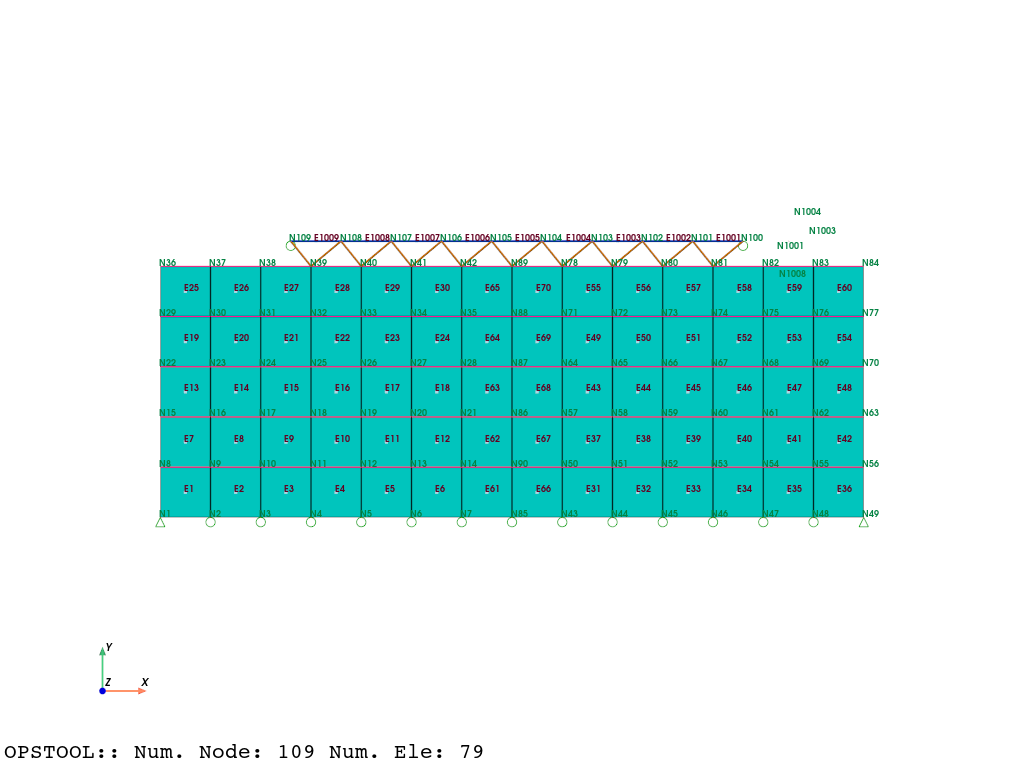

In [250]:
OPSVIS = opst.vis.pyvista
OPSVIS.set_plot_props(point_size=1, font_size=9, notebook=True)
OPSVIS.plot_model(show_node_numbering=True, show_ele_numbering=True).show(jupyter_backend="jupyterlab")

In [251]:
ODB = opst.post.CreateODB(
    odb_tag=1,
    model_update=True,
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",
)

In [252]:
ops.constraints("Transformation")
ops.test("NormDispIncr", 1e-05, 50, 0)
ops.algorithm("Newton")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.integrator("LoadControl", 1)
ops.analysis("Static")

In [253]:
# turn on initial state analysis feature
ops.InitialStateAnalysis("on")
# ensure soil material intially considers linear elastic behavior
ops.updateMaterialStage("-material", 1, "-stage", 0)
# set contact elements to be frictionless for gravity analysis
ops.setParameter("-val", 0, "-eleRange", 3050, 3058, "friction")
# analysis 4 steps, and fetch response
for _ in range(4):
    ops.analyze(1)
    ODB.fetch_response_step()

InitialStateAnalysis ON


In [254]:
ops.updateMaterialStage("-material", 1, "-stage", 1)
# analysis 4 steps, and fetch response
for _ in range(4):
    ops.analyze(1)
    ODB.fetch_response_step()
# designate end of initial state analysis (zeros displacements, keeps state variables)
ops.InitialStateAnalysis("off")
# turn on frictional behavior for beam contact elements
ops.setParameter("-val", 1, "-eleRange", 3050, 3058, "friction")

InitialStateAnalysis OFF
Domain::addParameter - parameter with tag 0 already exists in model


In [255]:
ops.wipeAnalysis()
ops.constraints("Transformation")
ops.test("NormDispIncr", 0.0001, 60)
ops.algorithm("KrylovNewton")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.integrator("LoadControl", 1)
ops.analysis("Static")

In [256]:
def remove_components(ele_tags, node_tags, nsteps=4):
    for etag in ele_tags:
        ops.remove("element", etag)
    for ntag in node_tags:
        ops.remove("node", ntag)
    # run analysis after object removal
    for _ in range(nsteps):
        ops.analyze(1)
        ODB.fetch_response_step()

In [257]:
PN_1 = 500000*UNIT.N
print(PN_1)
ops.timeSeries("Linear", 1)
ops.pattern("Plain", 1, 1)
ops.load(104, 0, -PN_1, 0)
ops.analyze(1)

500.0


0

In [258]:
# remove objects associated with lift 1
# soil elements
ele_tags = []
ele_tags += []  # contact element
# soil nodes
node_tags = []
node_tags += []  # lagrange multiplier node

remove_components(ele_tags, node_tags, nsteps=4)

print("Lift 1 removed")

Lift 1 removed


In [259]:
PN_2 = 5000*UNIT.N
print(PN_2)
ops.load(107, 0, -PN_2, 0)
ops.analyze(1)

5.0


0

In [260]:
ele_tags = []
ele_tags += []  # contact element
# soil nodes
node_tags = []
node_tags += []  # lagrange multiplier node

remove_components(ele_tags, node_tags, nsteps=4)

print("Lift 2 removed")

Lift 2 removed


In [261]:
ODB.save_response(zlib=True)

OPSTOOL ::  All responses data with _odb_tag = 1 saved in .opstool.output/RespStepData-1.nc!

In [262]:
import matplotlib.pyplot as plt
import opstool as opst
import opstool.vis.pyvista as opsvis

In [263]:
opsvis.set_plot_props(point_size=0, line_width=5, cmap="turbo", notebook=True)
opsvis.set_plot_props(
    scalar_bar_kargs={
        "label_font_size": 12,
        "title_font_size": 13,
        "position_x": 0.85,  # 0--1
    }
)

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

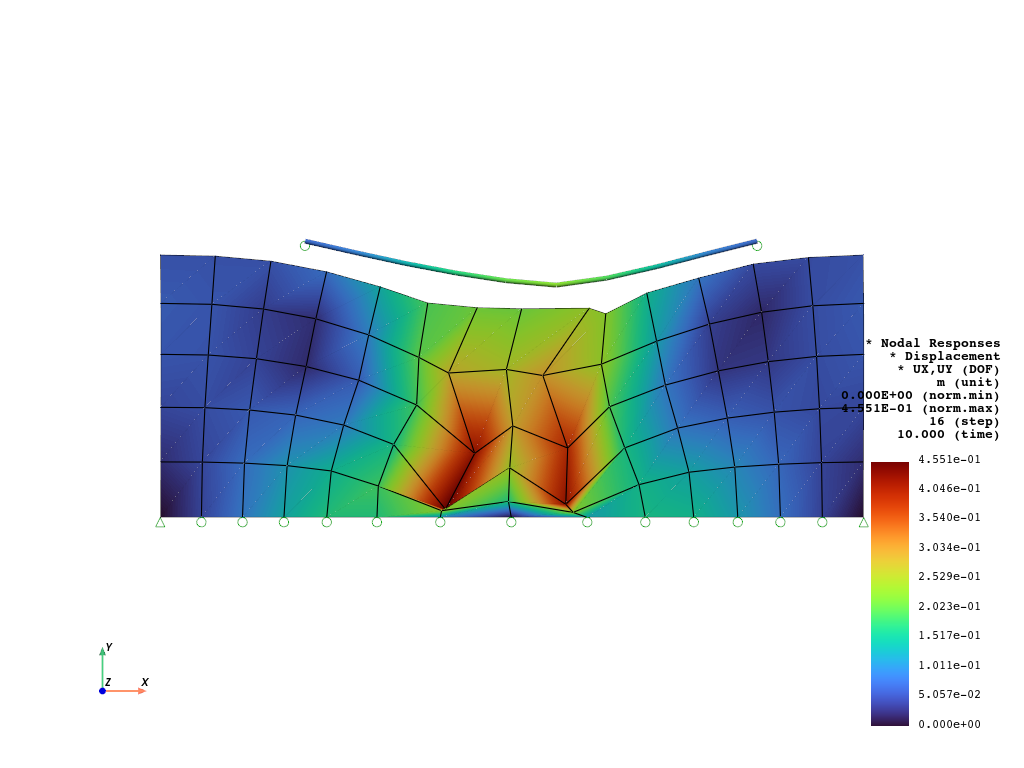

In [264]:
opsvis.plot_nodal_responses(
    odb_tag=1,
    slides=True,
    scale=2,
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).show(jupyter_backend="jupyterlab")

In [265]:
opsvis.plot_nodal_responses_animation(
    odb_tag=1,
    framerate=2,
    scale=2,
    savefig="NodalRespAnimationA.gif",
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).close()

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

Animation has been saved to NodalRespAnimationA.gif!


OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

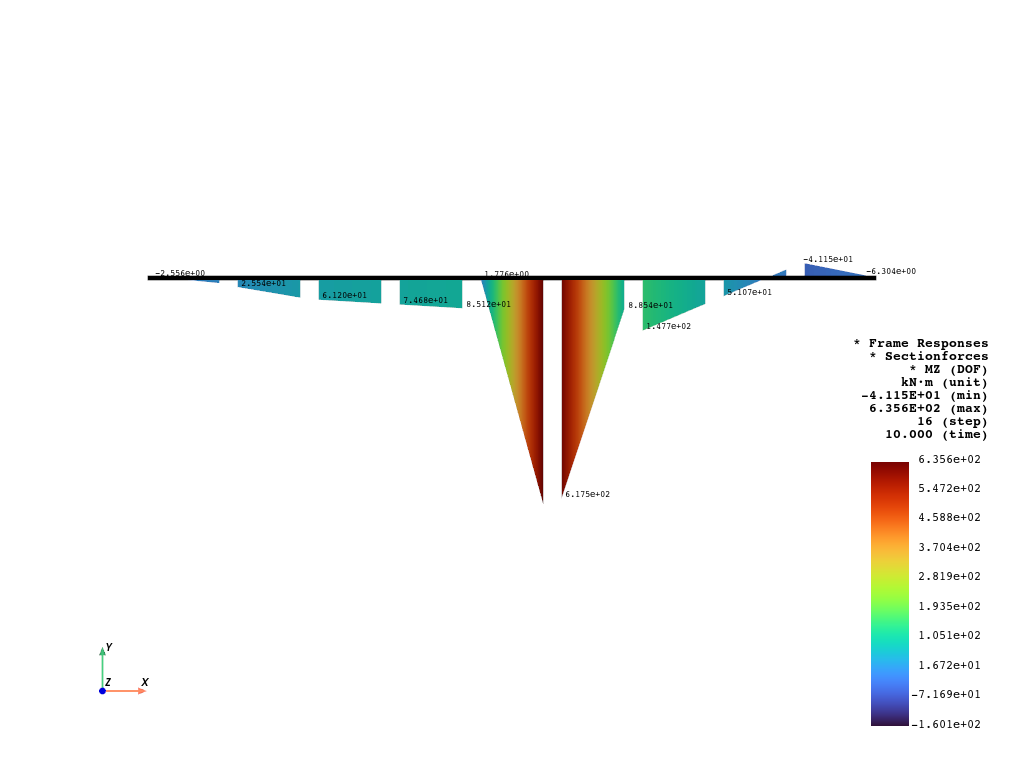

In [266]:
plotter = opsvis.plot_frame_responses(
    odb_tag=1,
    resp_type="sectionForces",
    resp_dof="MZ",
    unit_symbol="kN·m",
    show_values="eleMaxMin",
    scale=3,
    slides=True,
    style="surface",
    show_model=False,  # plot all model
    opacity=1.0,
    show_bc=False,
)
plotter.show(jupyter_backend="jupyterlab")